<>:93: SyntaxWarning: invalid escape sequence '\c'
<>:94: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:103: SyntaxWarning: invalid escape sequence '\c'
<>:111: SyntaxWarning: invalid escape sequence '\c'
<>:112: SyntaxWarning: invalid escape sequence '\c'
<>:153: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\c'
<>:94: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:103: SyntaxWarning: invalid escape sequence '\c'
<>:111: SyntaxWarning: invalid escape sequence '\c'
<>:112: SyntaxWarning: invalid escape sequence '\c'
<>:153: SyntaxWarning: invalid escape sequence '\m'
C:\Users\sukhi\AppData\Local\Temp\ipykernel_19200\193196771.py:93: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Roll [$^\circ$]')
C:\Users\sukhi\AppData\Local\Temp\ipykernel_19200\193196771.py:94: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f'RMSE: {r

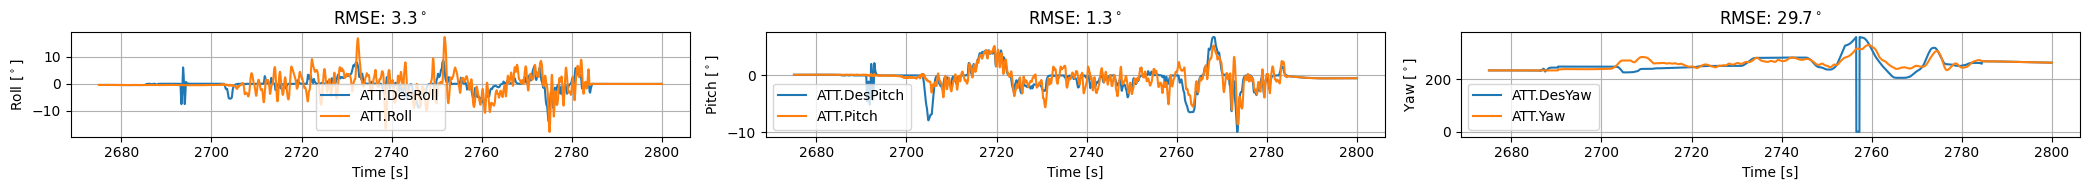

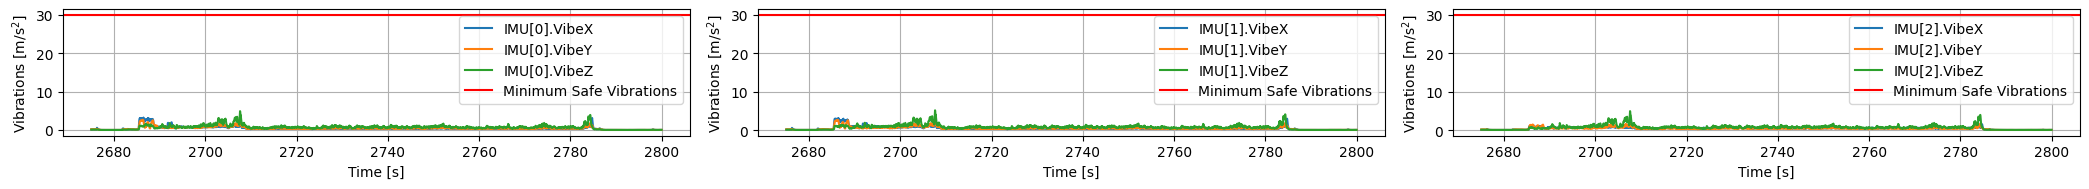

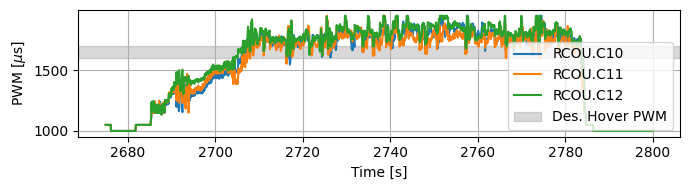

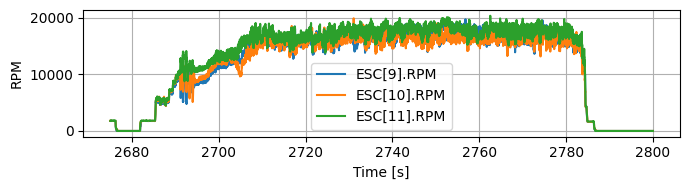

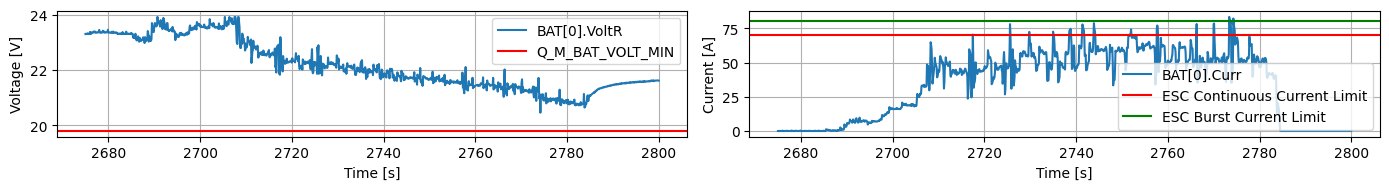

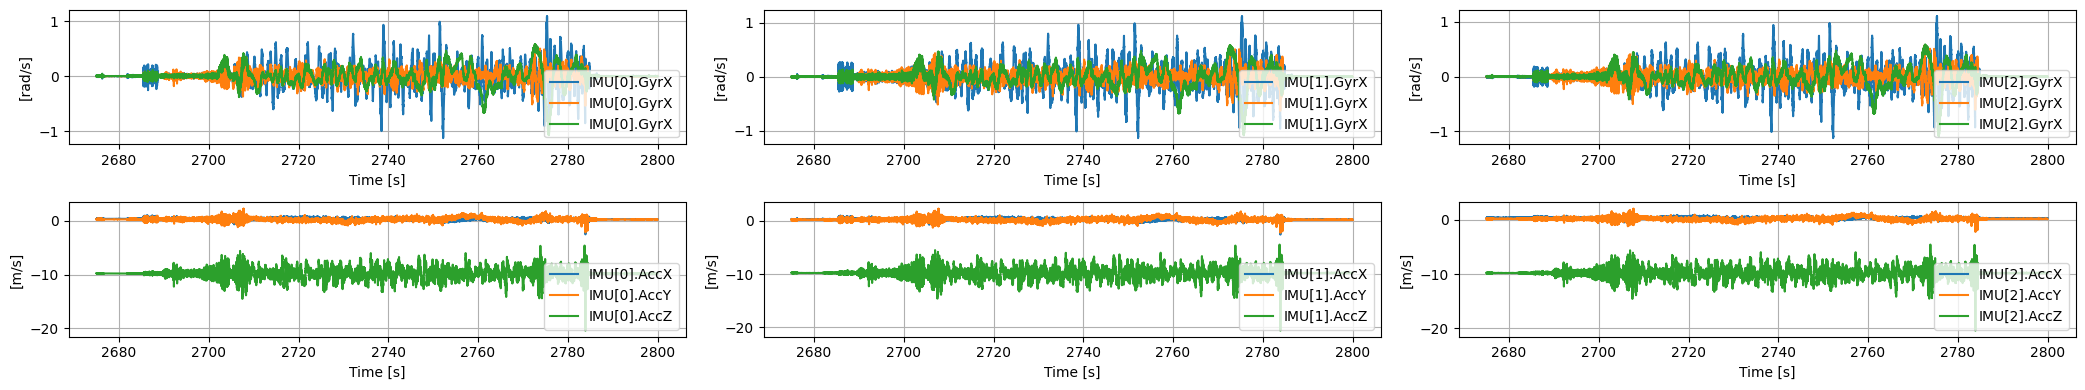

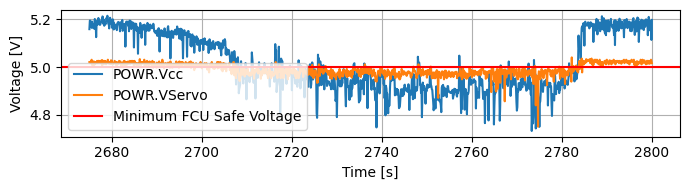

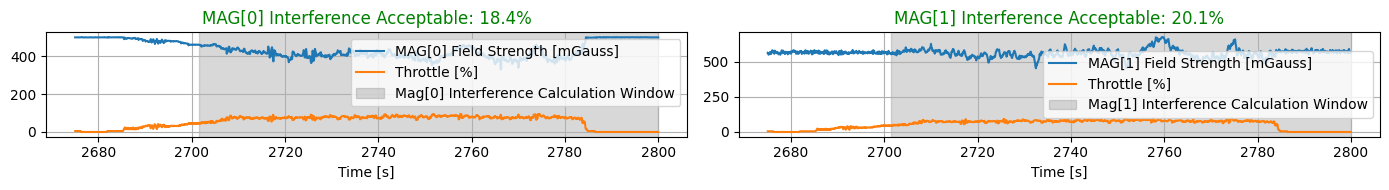

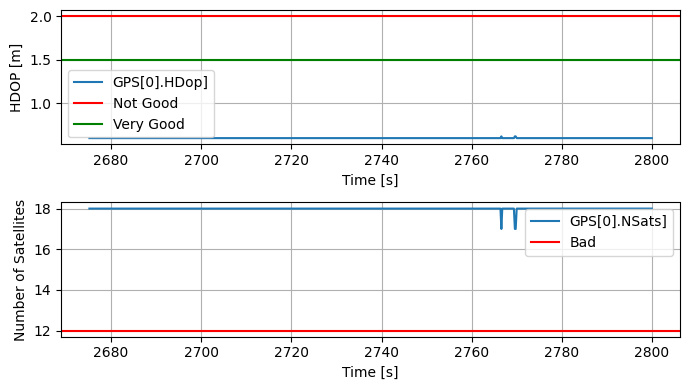

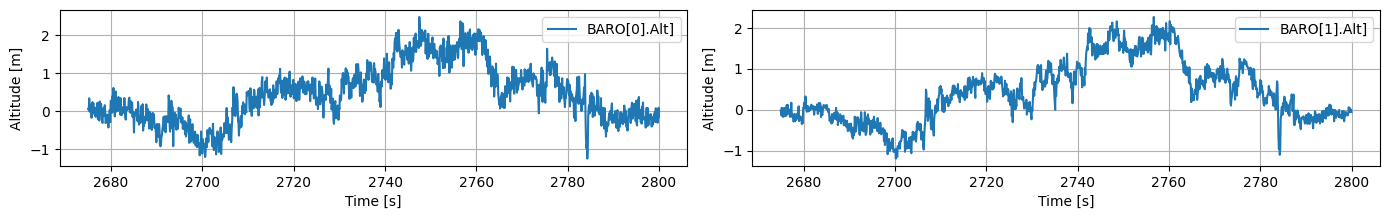

Summary Saved To summaries/2026-03-26/SUMMARY_2026-03-26.txt


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pymavlog import MavLog

class ArduPilotLogReviewer:
    def __init__(self, filedate:str, filepath:str, MOTOR_RCOU_CH:list, auto_detect_flight:bool=True, T_MIN:int=None, T_MAX:int=None, save_plots:bool=False):
        self.filedate = filedate
        self.filepath = filepath
        self.MOTOR_RCOU_CH = MOTOR_RCOU_CH
        self.auto_detect_flight = auto_detect_flight
        self.T_MIN = T_MIN
        self.T_MAX = T_MAX
        self.save_plots = save_plots

        # constants
        self.DES_HOVER_PWM = (1600, 1700)
        self.ESC_CONT_A = 70
        self.ESC_BURST_A = 80

        # directories
        os.makedirs(f'csvs/{self.filedate}', exist_ok=True)
        os.makedirs(f'plots/{self.filedate}', exist_ok=True)
        os.makedirs(f'summaries/{self.filedate}', exist_ok=True)

        # parse
        self.mavlog = MavLog(filepath=filepath)
        self.mavlog.parse()

        # detect flight window
        if auto_detect_flight:
            [self.T_MIN, self.T_MAX] = self.detect_flight_window()
        else:
            if T_MIN is None or T_MAX is None:
                raise ValueError("T_MIN and T_MAX must be provided when auto_detect_flight=False")
            self.T_MIN = T_MIN
            self.T_MAX = T_MAX

    def get_msg(self, msg:str):
        df = pd.DataFrame(self.mavlog.get(msg).fields)
        if msg != 'PARM':
            df = df[(df['TimeUS'] / 1e6 >= self.T_MIN) & (df['TimeUS'] / 1e6 <= self.T_MAX)]
        else:
            df = df
        return df    
    
    def detect_flight_window(self):
        msg = 'RCOU'
        df = pd.DataFrame(self.mavlog.get(msg).fields)

        pwm_min = self.get_msg('PARM').loc[self.get_msg('PARM')["Name"] == f'SERVO{self.MOTOR_RCOU_CH[0]}_MIN', "Value"].iloc[0]
        pwm_max = self.get_msg('PARM').loc[self.get_msg('PARM')["Name"] == f'SERVO{self.MOTOR_RCOU_CH[0]}_MAX', "Value"].iloc[0]
        pwm = df[f'C{MOTOR_RCOU_CH[0]}']

        time_us = df['TimeUS'].values / 1e6
        
        above_threshold = pwm > 1300
        
        diff = np.diff(above_threshold.astype(int))
        rise_indices = np.where(diff == 1)[0] + 1  
        fall_indices = np.where(diff == -1)[0]    
        
        flight_start_idx = rise_indices[0]
        flight_end_idx = fall_indices[-1]
        
        T_MIN = time_us[flight_start_idx]
        T_MAX = time_us[flight_end_idx]
        
        print(f"Flight Window Detected: {T_MIN:.1f}s - {T_MAX:.1f}s (Duration: {T_MAX - T_MIN:.1f}s)")
        
        return [T_MIN, T_MAX]
    
    def plot_att(self):
        msg = 'ATT'
        df = self.get_msg(msg=msg)
        self.save_csv(df, msg)

        error_roll = df['Roll'] - df['DesRoll']
        error_pitch = df['Pitch'] - df['DesPitch']
        error_yaw = df['Yaw'] - df['DesYaw']

        rmse_roll = np.sqrt(np.mean(error_roll ** 2))
        rmse_pitch = np.sqrt(np.mean(error_pitch ** 2))
        rmse_yaw = np.sqrt(np.mean(error_yaw ** 2))

        plt.figure(figsize=(21, 2))

        plt.subplot(1, 3, 1)
        plt.plot(df['TimeUS'] / 1e6, df['DesRoll'], label=msg+'.DesRoll')
        plt.plot(df['TimeUS'] / 1e6, df['Roll'], label=msg+'.Roll')
        plt.xlabel('Time [s]')
        plt.ylabel('Roll [$^\circ$]')
        plt.title(f'RMSE: {rmse_roll:.1f}$^\circ$')
        plt.grid(1)
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(df['TimeUS'] / 1e6, df['DesPitch'], label=msg+'.DesPitch')
        plt.plot(df['TimeUS'] / 1e6, df['Pitch'], label=msg+'.Pitch')
        plt.xlabel('Time [s]')
        plt.ylabel('Pitch [$^\circ$]')
        plt.title(f'RMSE: {rmse_pitch:.1f}$^\circ$') 
        plt.grid(1)
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(df['TimeUS'] / 1e6, df['DesYaw'], label=msg+'.DesYaw')
        plt.plot(df['TimeUS'] / 1e6, df['Yaw'], label=msg+'.Yaw')
        plt.xlabel('Time [s]')
        plt.ylabel('Yaw [$^\circ$]')
        plt.title(f'RMSE: {rmse_yaw:.1f}$^\circ$') 
        plt.grid(1)
        plt.legend()

        self.save_plot(msg)
    
    def plot_vibes(self):
        msg = 'VIBE'
        df = self.get_msg(msg=msg)
        imu_groups = df.groupby('IMU')

        plt.figure(figsize=(7 * df['IMU'].nunique(), 2))
        
        for i, idx in imu_groups:
            idx = idx.reset_index(drop=True)
            self.save_csv(idx, msg+f'VIBE[{i}]')
            plt.subplot(1, df['IMU'].nunique(), i + 1)
            plt.plot(idx['TimeUS'] / 1e6, idx['VibeX'], label=f'IMU[{i}].VibeX')
            plt.plot(idx['TimeUS'] / 1e6, idx['VibeY'], label=f'IMU[{i}].VibeY')
            plt.plot(idx['TimeUS'] / 1e6, idx['VibeZ'], label=f'IMU[{i}].VibeZ')
            plt.axhline(30, color='red', label='Minimum Safe Vibrations')
            plt.xlabel('Time [s]')
            plt.ylabel('Vibrations [m/s$^2$]')
            plt.grid(1)
            plt.legend()

        self.save_plot(msg)

    def plot_rcou(self):
        msg = 'RCOU'
        df = self.get_msg(msg=msg)
        self.save_csv(df, msg)

        plt.figure(figsize=(7, 2))

        for i, idx in enumerate(self.MOTOR_RCOU_CH):
            plt.plot(df['TimeUS'] / 1e6, df[f'C{idx}'], label=msg+f'.C{idx}')

        plt.axhspan(*self.DES_HOVER_PWM, color='gray', alpha=0.3, label='Des. Hover PWM')
        
        plt.xlabel('Time [s]')
        plt.ylabel('PWM [$\mu$s]')
        plt.grid(1)
        plt.legend()
        self.save_plot(msg)
    
    def plot_esc(self):
        msg = 'ESC'
        df = self.get_msg(msg=msg)
        esc_groups = df.groupby("Instance")

        plt.figure(figsize=(7, 2))

        for i, idx in esc_groups:
            idx = idx.reset_index(drop=True)
            self.save_csv(idx, f"ESC[{i}].RPM")

            plt.plot(idx['TimeUS'] / 1e6, idx['RPM'], label=f'ESC[{i}].RPM')
            
        plt.xlabel('Time [s]')
        plt.ylabel('RPM')
        plt.grid(1)
        plt.legend()
            
        self.save_plot(msg)

    def plot_bat(self):
        msg = 'BAT'
        df = self.get_msg(msg=msg)
        bat_groups = df.groupby('Inst')

        q_m_bat_volt_min = self.get_msg('PARM').loc[self.get_msg('PARM')["Name"] == 'Q_M_BAT_VOLT_MIN', "Value"].iloc[0]

        plt.figure(figsize=(14, 2))

        for i, idx in bat_groups:
            idx = idx.reset_index(drop=True)
            self.save_csv(idx, msg+f'[{i}]')

            plt.subplot(1, 2, 1)
            plt.plot(idx['TimeUS'] / 1e6, idx['VoltR'], label=f'BAT[{i}].VoltR')
            plt.axhline(q_m_bat_volt_min, color='red', label='Q_M_BAT_VOLT_MIN')
            plt.xlabel('Time [s]')
            plt.ylabel("Voltage [V]")
            plt.grid(1)
            plt.legend()
            plt.subplot(1, 2, 2)
            plt.plot(idx['TimeUS'] / 1e6, idx['Curr'], label=f'BAT[{i}].Curr')
            plt.axhline(self.ESC_CONT_A, color='red', label='ESC Continuous Current Limit')
            plt.axhline(self.ESC_BURST_A, color='green', label='ESC Burst Current Limit')
            plt.xlabel('Time [s]')
            plt.ylabel("Current [A]")
            plt.grid(1)
            plt.legend()
            
        self.save_plot(msg)

    def plot_imus(self):
        msg = 'IMU'
        df = self.get_msg(msg=msg)
        imu_groups = df.groupby('I')

        plt.figure(figsize=(7 * df['I'].nunique(), 4))

        for i, idx in imu_groups:
            idx = idx.reset_index(drop=True)
            self.save_csv(idx, msg+f"[{i}]")

            plt.subplot(2, df['I'].nunique(), i + 1)
            plt.plot(idx['TimeUS'] / 1e6, idx['GyrX'], label=f'IMU[{i}].GyrX')
            plt.plot(idx['TimeUS'] / 1e6, idx['GyrY'], label=f'IMU[{i}].GyrX')
            plt.plot(idx['TimeUS'] / 1e6, idx['GyrZ'], label=f'IMU[{i}].GyrX')
            plt.xlabel('Time [s]')
            plt.ylabel('[rad/s]')
            plt.grid(1)
            plt.legend()

            plt.subplot(2, df['I'].nunique(), i + df['I'].nunique() + 1)
            plt.plot(idx['TimeUS'] / 1e6, idx['AccX'], label=f'IMU[{i}].AccX')
            plt.plot(idx['TimeUS'] / 1e6, idx['AccY'], label=f'IMU[{i}].AccY')
            plt.plot(idx['TimeUS'] / 1e6, idx['AccZ'], label=f'IMU[{i}].AccZ')
            plt.xlabel('Time [s]')
            plt.ylabel('[m/s]')
            plt.grid(1)
            plt.legend()
            
        self.save_plot(msg)

    def plot_powr(self):
        msg = 'POWR'
        df = self.get_msg(msg=msg)
        self.save_csv(df, msg)

        plt.figure(figsize=(7, 2))
        plt.plot(df['TimeUS'] / 1e6, df['Vcc'], label=msg+'.Vcc')
        plt.plot(df['TimeUS'] / 1e6, df['VServo'], label=msg+'.VServo')
        plt.axhline(5, color='red', label='Minimum FCU Safe Voltage')
        plt.xlabel('Time [s]')
        plt.ylabel("Voltage [V]")
        plt.grid(1)
        plt.legend()
        self.save_plot(msg)

    def plot_compass_interference(self):
        msg = 'MAG'
        df = self.get_msg(msg=msg)
        mag_groups = df.groupby('I')

        plt.figure(figsize=(7 * df['I'].nunique(), 2))

        for i, idx in mag_groups:
            idx = idx.reset_index(drop=True)
            mag_field = np.sqrt(idx['MagX']**2 + idx['MagY']**2 + idx['MagZ']**2)
            pwm_min = self.get_msg('PARM').loc[self.get_msg('PARM')["Name"] == f'SERVO{self.MOTOR_RCOU_CH[0]}_MIN', "Value"].iloc[0]
            pwm_max = self.get_msg('PARM').loc[self.get_msg('PARM')["Name"] == f'SERVO{self.MOTOR_RCOU_CH[0]}_MAX', "Value"].iloc[0]
            throttle = (self.get_msg(msg='RCOU')[f'C{self.MOTOR_RCOU_CH[0]}'] - pwm_min) / (pwm_max - pwm_min) * 100
            throttle = throttle.reset_index(drop=True)

            baseline_window = throttle > 20
            baseline_mag = mag_field[baseline_window].mean()

            baseline_times = idx['TimeUS'][baseline_window]
            baseline_start = baseline_times.iloc[0]
            baseline_end = baseline_times.iloc[-1]

            mag_interference = ((mag_field - baseline_mag) / baseline_mag) * 100
            
            mag_interference_max = mag_interference.max()
            
            if mag_interference_max < 30:
                assessment = 'Acceptable'
                color = 'green'
            elif mag_interference_max < 60:
                assessment = 'Gray Zone (30-60%)'
                color = 'orange'
            else:
                assessment = 'Bad (>60%)'
                color = 'red'

            mag_df = pd.DataFrame({
                "TimeUS": idx['TimeUS'],
                "MagField": mag_field,
                "Throttle": throttle,
            })

            self.save_csv(mag_df, msg+f'[{i}]')

            plt.subplot(1, df['I'].nunique(), i + 1)
            plt.plot(idx['TimeUS'] / 1e6, mag_field, label=f'MAG[{i}] Field Strength [mGauss]')
            plt.plot(self.get_msg(msg='RCOU')['TimeUS'] / 1e6, throttle, label='Throttle [%]')
            plt.axvspan(baseline_start /1e6, baseline_end /1e6, alpha=0.3, color='gray', label=f'Mag{[i]} Interference Calculation Window')
            plt.xlabel('Time [s]')
            plt.ylabel('')
            plt.grid(1)
            plt.legend()
            plt.title(f'MAG[{i}] Interference {assessment}: {mag_interference_max:.1f}%', color=color)
        
        self.save_plot(msg)

    def plot_gps(self):
        msg = 'GPS'
        df = self.get_msg(msg=msg)
        gps_groups = df.groupby('I')

        plt.figure(figsize=(7 * df['I'].nunique(), 4))

        for i, idx in gps_groups:
            idx = idx.reset_index(drop=True)
            self.save_csv(idx, msg+f"[{i}]")

            plt.subplot(2, df['I'].nunique(), i + 1)
            plt.plot(idx['TimeUS'] / 1e6, idx['HDop'], label=f'GPS[{i}].HDop]')
            plt.axhline(2, color='red', label='Not Good')
            plt.axhline(1.5,color='green', label='Very Good')
            plt.xlabel('Time [s]')
            plt.ylabel('HDOP [m]')
            plt.grid(1)
            plt.legend()

            plt.subplot(2, df['I'].nunique(), i + df['I'].nunique() + 1)
            plt.plot(idx['TimeUS'] / 1e6, idx['NSats'], label=f'GPS[{i}].NSats]')
            plt.axhline(12, color='red', label='Bad')
            plt.xlabel('Time [s]')
            plt.ylabel('Number of Satellites')
            plt.grid(1)
            plt.legend()

        self.save_plot(msg)

    def plot_baro(self):
        msg = 'BARO'
        df = self.get_msg(msg=msg)
        gps_groups = df.groupby('I')

        plt.figure(figsize=(7 * df['I'].nunique(), 4))

        for i, idx in gps_groups:
            idx = idx.reset_index(drop=True)
            self.save_csv(idx, msg+f"[{i}]")

            plt.subplot(2, df['I'].nunique(), i + 1)
            plt.plot(idx['TimeUS'] / 1e6, idx['Alt'], label=f'BARO[{i}].Alt]')
            plt.xlabel('Time [s]')
            plt.ylabel('Altitude [m]')
            plt.grid(1)
            plt.legend()

        self.save_plot(msg)

    def save_plot(self, name):
        if self.save_plots:
            filepath = f"plots/{self.filedate}/{name}_{self.filedate}.png"
            plt.tight_layout()
            plt.savefig(filepath, dpi=300)
            plt.show()
        else:
            plt.show()

    def save_csv(self, df, name):
        filepath = f"csvs/{self.filedate}/{name}_{self.filedate}.csv"
        df = df.copy()
        if 'TimeUS' in df.columns:
            df.rename(columns={'TimeUS': 'TimeS'}, inplace=True)
            df['TimeS'] /= 1e6

        df.to_csv(filepath, index=False)

    def generate_summary(self):
        summary_lines = []

        duration = self.T_MAX - self.T_MIN
        summary_lines.append(f"Flight Time: {duration:.1f} s")

        try:
            bat = self.get_msg('BAT')
            min_volt = bat['VoltR'].min()
            max_curr = bat['Curr'].max()
            mean_curr = np.mean(bat['Curr'].max())

            summary_lines.append(f"Minimum Battery Voltage: {min_volt:.2f} V")
            summary_lines.append(f"Maximum Battery Current: {max_curr:.2f} A")

            if max_curr > self.ESC_BURST_A:
                summary_lines.append("WARNING: ESC Burst Current Exceeded!")
            elif mean_curr > self.ESC_CONT_A:
                summary_lines.append("WARNING: ESC Continuous Current Exceeded!")

        except:
            summary_lines.append("Battery Data Unavailable.")

        try:
            vibe = self.get_msg('VIBE')
            max_vibe = vibe[['VibeX', 'VibeY', 'VibeZ']].max().max()

            summary_lines.append(f"Max Vibration: {max_vibe:.2f} m/s/s")

            if max_vibe > 60:
                summary_lines.append("WARNING: Excessive Vibrations!")
            elif max_vibe > 30:
                summary_lines.append("WARNING: Vibrations In Caution Range!")

        except:
            summary_lines.append("Vibration Data Unavailable.")

        try:
            gps = self.get_msg('GPS')
            min_sats = gps['NSats'].min()
            max_hdop = gps['HDop'].max()

            summary_lines.append(f"Minimum Satellites: {min_sats}")
            summary_lines.append(f"Maximum HDOP: {max_hdop:.2f}")

            if min_sats < 12:
                summary_lines.append("WARNING: Low Satellite Count!")
            if max_hdop > 2:
                summary_lines.append("WARNING: Poor GPS Accuracy!")

        except:
            summary_lines.append("GPS Data Unavailable.")

        try:
            msg = 'MAG'
            df = self.get_msg(msg=msg)
            mag_groups = df.groupby('I')

            max_interference_all = 0

            for i, idx in mag_groups:
                idx = idx.reset_index(drop=True)

                mag_field = np.sqrt(idx['MagX']**2 + idx['MagY']**2 + idx['MagZ']**2)

                pwm_min = self.get_msg('PARM').loc[
                    self.get_msg('PARM')["Name"] == f'SERVO{self.MOTOR_RCOU_CH[0]}_MIN', "Value"
                ].iloc[0]

                pwm_max = self.get_msg('PARM').loc[
                    self.get_msg('PARM')["Name"] == f'SERVO{self.MOTOR_RCOU_CH[0]}_MAX', "Value"
                ].iloc[0]

                throttle = (self.get_msg('RCOU')[f'C{self.MOTOR_RCOU_CH[0]}'] - pwm_min) / (pwm_max - pwm_min) * 100
                throttle = throttle.reset_index(drop=True)

                baseline_window = throttle > 20
                baseline_mag = mag_field[baseline_window].mean()

                mag_interference = ((mag_field - baseline_mag) / baseline_mag) * 100
                max_interference = mag_interference.max()

                max_interference_all = max(max_interference_all, max_interference)

            summary_lines.append(f"Maximum Compass Interference: {max_interference_all:.1f}%")

            if max_interference_all > 60:
                summary_lines.append("WARNING: Compass Interference Is BAD (>60%)!")
            elif max_interference_all > 30:
                summary_lines.append("WARNING: Compass Interference In Gray Zone (30–60%)!")

        except:
            summary_lines.append("Compass Interference Data Unavailable")

        try:
            df = self.get_msg('POWR')
            min_vcc = df['Vcc'].min()

            summary_lines.append(f"Min FCU Voltage: {min_vcc:.2f} V")

            if min_vcc < 5.0:
                summary_lines.append("WARNING: FCU Voltage Dropped Below Safe Level (5V)!")

        except:
            summary_lines.append("FCU Voltage Data Unavailable")

        return summary_lines
    
    def save_summary(self):
        summary = self.generate_summary()

        filepath = f"summaries/{self.filedate}/SUMMARY_{self.filedate}.txt"

        with open(filepath, "w") as f:
            f.write(f"ArduPilotLogReviewer Summary\n")
            f.write("="*40 + "\n\n")

            for line in summary:
                f.write(line + "\n")

        print(f"Summary Saved To {filepath}")

if __name__ == "__main__":
    filedate = "2026-03-26"
    filepath = f"logs/{filedate}.BIN"
    MOTOR_RCOU_CH = [10, 11, 12]

    reviewer = ArduPilotLogReviewer(filedate=filedate, filepath=filepath, MOTOR_RCOU_CH=MOTOR_RCOU_CH, auto_detect_flight=False, T_MIN=2675, T_MAX=2800, save_plots=True)
    reviewer.plot_att()
    reviewer.plot_vibes()
    reviewer.plot_rcou()
    reviewer.plot_esc()
    reviewer.plot_bat()
    reviewer.plot_imus()
    reviewer.plot_powr()
    reviewer.plot_compass_interference()
    reviewer.plot_gps()
    reviewer.plot_baro()
    reviewer.save_summary()